#INFORMACIÓN GENERAL

UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO

ESCUELA PROFESIONAL DE INGENIERÍA INFORMÁTICA Y DE SISTEMAS

INTELIGENCIA ARTIFICIAL

LABORATORIO 06: ALGORITMO MINIMAX - JUEGO "TRES EN RAYA"

##MARCO TEÓRICO

Para realizar esta búsqueda se consideran 2 jugadores, a los que se les denomina Max y Min, los cuales son contrincantes y juegan de manera alternada. Igualmente, se asume que ambos jugadores seleccionarán sus movimientos siempre de la mejor manera posible.

La idea de la búsqueda consiste en asignar la posición actual del tablero como nodo raíz, el generador de movimientos para encontrar los nodos del siguiente nivel de profundidad, y así consecutivamente.


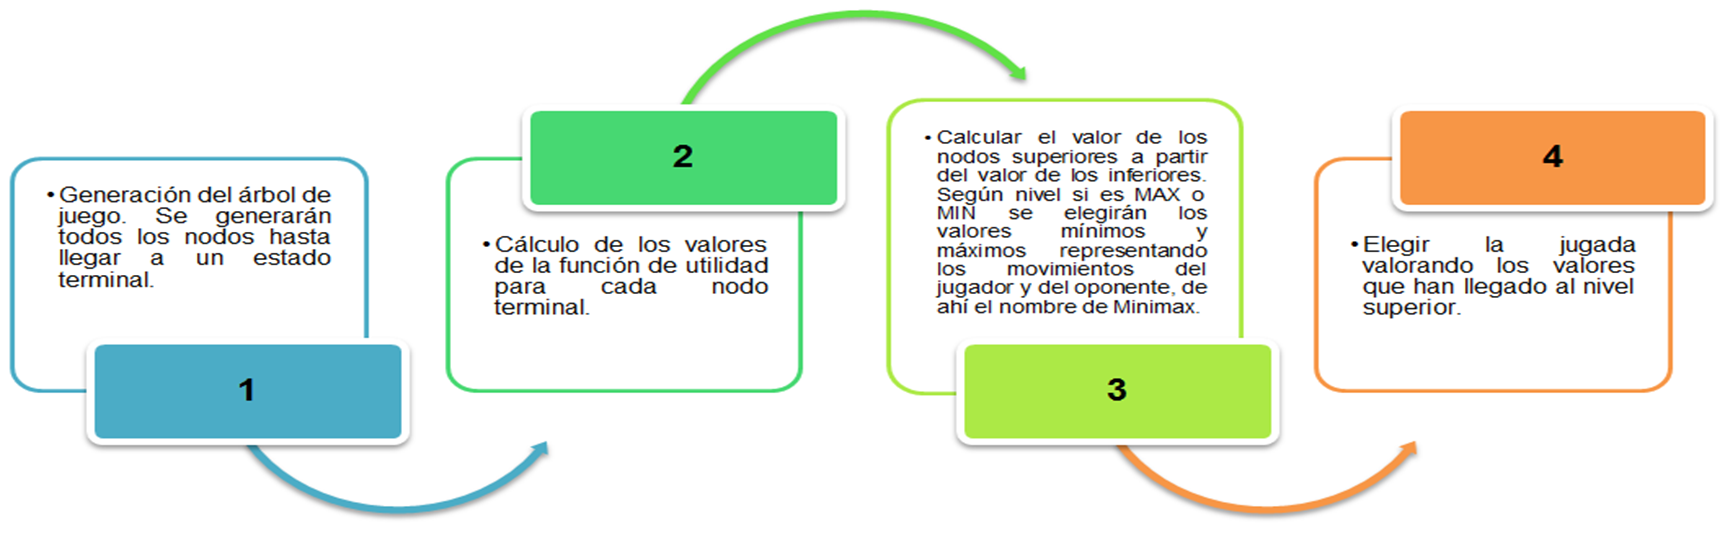

Juego "TRES EN RAYA"

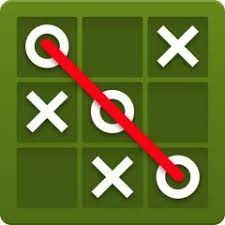

Árbol de jugadas para el juego "TRES EN RAYA"

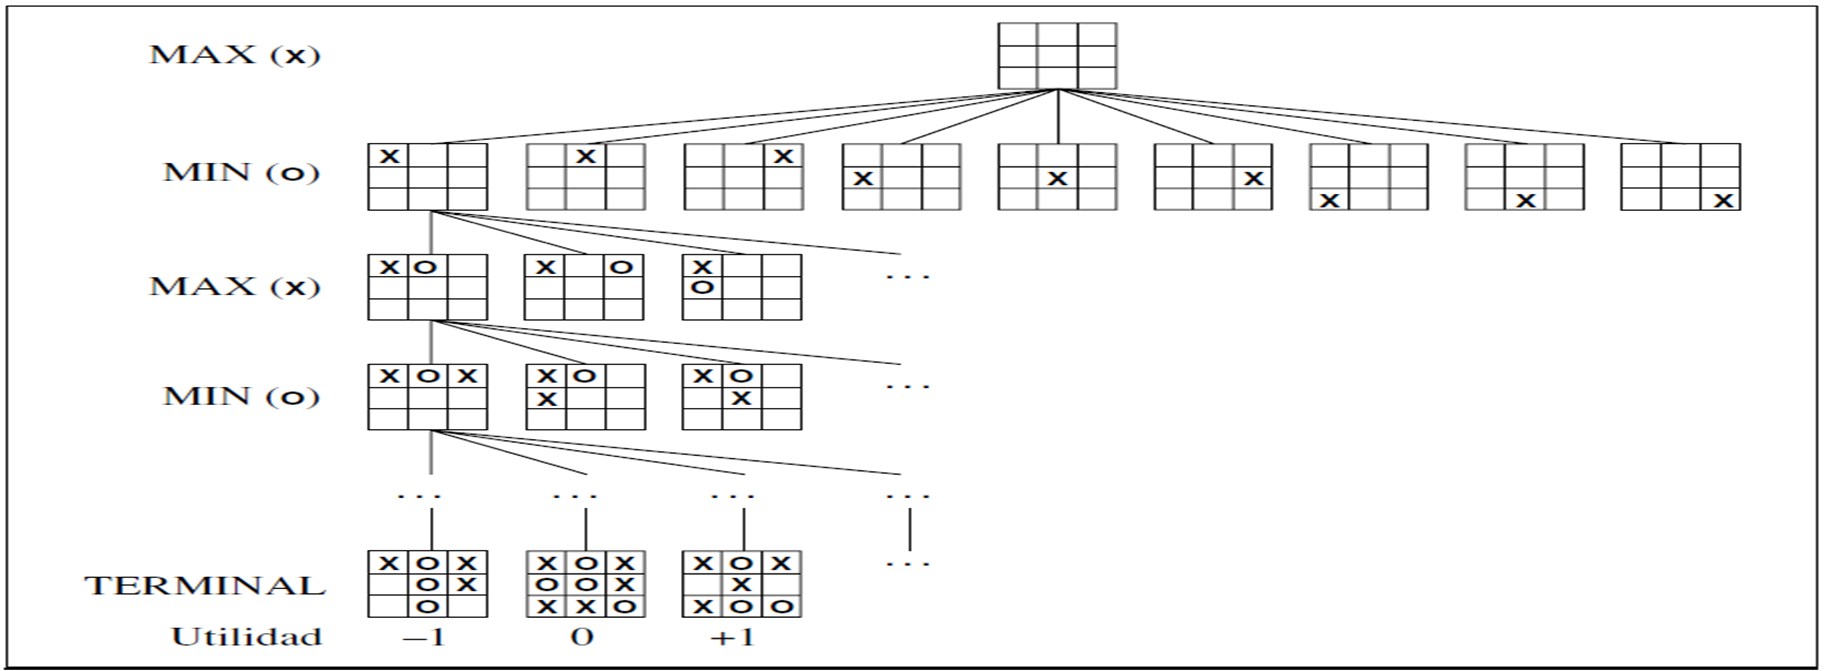

##IMPLEMENTACIÓN

Implementación del juego "TRES EN RAYA" haciendo uso del algoritmo MiniMAX

In [ ]:
# -- Librerías
from google.colab import output # -- Para limpiar pantalla después de cada jugada
from math import inf as infinity # -- Para inicializar los valores de alfa y beta
from random import choice # -- Para escoger al azar un valor de una lista

# -- Clase para juego "TRES EN RAYA" - Implementado con algoritmo MiniMax
class TresEnRaya:
  # -- Constructor
  def __init__(self):
    self.tablero = [[0, 0, 0],
                    [0, 0, 0],
                    [0, 0, 0]]
    self.agente = +1
    self.aSimbolo = 'X'
    self.humano = -1
    self.hSimbolo = 'O'

  # -- Nombre
  def __str__(self):
    return 'Tres en raya'

  # -- Método para limpiar la pantalla
  def limpiarPantalla(self):
    output.clear()

  # -- Método para poner instrucciones para el juego
  def ponerInstrucciones(self):
    # -- Mostrar instrucciones
    self.limpiarPantalla()
    print('BIENVENIDOS AL JUEGO "TRES EN RAYA"')
    print('══════════════════════════════════')
    print('')
    print('INSTRUCCIONES')
    print('Para jugar en su respectivo turno debe digitar el número de la respectiva celda.')
    print('La numeración de las celdas del tablero se muestra a continuación:')
    # -- Mostrar el tablero con la numeración de las celdas
    texto = ''
    k = 0
    for i in range(0, 3):
      for j in range(0, 3):
        k += 1
        texto += (' ' if j == 0 else '│ ' ) + str(k) + ' '
      texto += ' \n'
      texto += '───┼───┼─── \n' if i < 2 else '\n'
    print(texto)
    print('Presione <ENTER> para empezar el juego')
    tecla = input()
    self.limpiarPantalla()

  # -- Método para iniciar el juego
  def iniciarJuego(self):
    self.ponerInstrucciones()
    # -- Leer con que símbolo (X o O) desea jugar el humano
    simbolo = input('Indique si desea jugar con X o O: ').upper()
    # -- Validar
    while simbolo != 'O' and simbolo != 'X':
      print('ERROR: Símbolo no permitido.')
      simbolo = input('Indique si desea jugar con X o O: ').upper()
    # -- Definir símbolo para el agente en función a lo escogido por el humano
    self.hSimbolo = simbolo
    self.aSimbolo = 'O' if self.hSimbolo == 'X' else 'X'
    # -- Definir quién empieza a jugar
    self.limpiarPantalla()
    iniciaHumano = input('¿Desea empezar usted? Digite S --> Si o N --> No]: ').upper()
    while not (iniciaHumano.startswith('S') or iniciaHumano.startswith('N')):
      print('ERROR.')
      iniciaHumano = input('¿Desea empezar usted? Digite S --> Si o N --> No]: ').upper()
    # -- Devolver si inicia el juego el humano
    return iniciaHumano.startswith('S')

  # -- Método para determinar una lista de las celdas vacías del tablero
  #    Sólo se puede efectuar la siguiente jugada sobre estas celdas
  #    Termina el juego si no hay celdas vacías
  def celdasVacias(self, estado):
    celdas = []
    for x, fila in enumerate(estado):
      celdas += [[x,y] for y, celda in enumerate(fila) if celda == 0 ]
    return celdas

  # -- Método para definir si las celdas de las posiciones c1, c2 y c3 son o no iguales
  #    Considerar que, si c1, c2 o c3 es un número de celda cuyo valor está entre 1 y 9
  #    Entonces: Fila = (c-1)//3, Columna = (c-1)%3
  def iguales(self, estado, c1, c2, c3, jugador):
    return jugador == estado[(c1-1)//3][(c1-1)%3] == estado[(c2-1)//3][(c2-1)%3] == estado[(c3-1)//3][(c3-1)%3]

  # -- Método para determinar si un jugador gana no en un determinado estado
  #    Considerar que se debe verificar si hay tres en raya en las filas columnas y diagonales
  def ganaJugador(self, estado, jugador):
    return self.iguales(estado,1,2,3,jugador) or self.iguales(estado,4,5,6,jugador) or self.iguales(estado,7,8,9,jugador) or \
           self.iguales(estado,1,4,7,jugador) or self.iguales(estado,2,5,8,jugador) or self.iguales(estado,3,6,9,jugador) or \
           self.iguales(estado,1,5,9,jugador) or self.iguales(estado,3,5,7,jugador)

  # -- Método para determinar si hay ganador
  #    Verifica el tablero en el estado actual y determina si hay ganador (agente o humano)
  def hayGanador(self, estado):
    return +1 if self.ganaJugador(estado, self.agente) else (-1 if self.ganaJugador(estado, self.humano) else 0)

  # -- Método para determinar si terminó el juego
  def terminoJuego(self):
    return (len(self.celdasVacias(self.tablero)) == 0) or (self.hayGanador(self.tablero) != 0)

  # -- Método que implementa el algoritmo MiniMax, que permitirá determinar la mejor jugada.
  def minimax(self, estado, nivel, jugador):
    # -- Inicializar la mejor jugada
    mejorJugada = [-1, -1, -infinity] if jugador == self.agente else [-1, -1, +infinity]

    # -- Verificar si ya no hay celdas para jugar o hay un estado ganador
    #    un estado ganador corresponde a: -1 (gana humano), 1 (gana agente) y 0 (empate)
    ganador = self.hayGanador(estado)
    if nivel == 0 or ganador != 0 :
        return [-1, -1, ganador]

    # -- Efectuar el proceso de evaluar las posibles jugadas, considerando sólo
    #    las celdas vacías.
    #    Es un proceso recursivo nivel a nivel
    for x,y in self.celdasVacias(estado):
        # -- Asumir que el jugador juega en la celda vacía correspondiente
        estado[x][y] = jugador
        # -- Determinar la mejor jugada para este nuevo estado
        score = self.minimax(estado, nivel - 1, -jugador)
        # -- Como sólo se asumió la jugada, devolver el estado a su estado anterior
        estado[x][y] = 0
        score[0], score[1] = x, y
        # -- Actualizar la mejor jugada, dependiendo si es max (agente) o min (humano)
        if jugador == self.agente:
            if score[2] > mejorJugada[2]:
                mejorJugada = score  # max
        else:
            if score[2] < mejorJugada[2]:
                mejorJugada = score  # min

    return mejorJugada

  # -- Mostrar tablero
  def mostrarTablero(self, estado):
    # -- Limpiar pantalla antes de mostrar tablero
    self.limpiarPantalla()
    # -- Determinar que caracteres debe mostrarse en pantalla
    dchar = {-1: self.hSimbolo, 0:' ', 1: self.aSimbolo}
    # -- Concatenar en un texto todo el tablero
    texto = ''
    for i in range(0, 3):
      for j in range(0, 3):
        simbolo = estado[i][j]
        texto += (' ' if j == 0 else '│ ' ) + dchar[simbolo] + ' '
      texto += ' \n'
      texto += '───┼───┼─── \n' if i < 2 else '\n'
    print(texto)

  # -- Método para implementar la lógica del juego del agente
  def juegaAgente(self):
    # -- Mostrar el tablero para que juegue el agente
    self.mostrarTablero(self.tablero)
    # -- La primera jugada realizarla al azar (Si todas las celdas están vacías)
    nivel = len(self.celdasVacias(self.tablero))
    if nivel == 9:
        x = choice([0, 1, 2])
        y = choice([0, 1, 2])
    else:
        # -- En las siguientes jugadas determinar la mejor, en base a MiniMax
        #    En consecuencia, determinar la mejor jugada
        mov = self.minimax(self.tablero, nivel, self.agente)
        x, y = mov[0], mov[1]
    # -- Poner en el tablero el símbolo en las coordenadas de la casilla correspondiente a la mejor jugada
    self.tablero[x][y] = self.agente

  # -- Método para implementar la lógica del juego del humano
  def juegaHumano(self):
    # -- Mostrar tablero para que juegue humano
    self.mostrarTablero(self.tablero)
    # -- Determinar números de celdas en los que se puede aún efectuar movimientos
    #    Si k identifica las celdas con un número entre 1 y 9,
    #    Entonces: Fila = (k-1)//3, Columna = (k-1)%3
    celdas = [k for k in range(1,10) if self.tablero[(k-1)//3][(k-1)%3] == 0]
    # -- Leer validando celda a jugar por el humano
    mov = -1
    while mov not in celdas:
      print('Las celdas donde aún se puede jugar son:', celdas)
      mov = int(input('Ingrese celda a jugar: '))
    # -- Recuperar coordenadas x, y de la celda y efectuar movimiento
    x, y = (mov - 1) // 3, (mov - 1) % 3
    self.tablero[x][y] = self.humano

  # -- Método para mostrar el resultado del juego
  def mostrarResultado(self):
    # -- Determinar el resultado
    ganador = self.hayGanador(self.tablero)
    resultado = '!FELICITACIONES! Ud. Ganó' if ganador == -1 else ('Lo siento. Ud. Perdió' if ganador == 1 else 'EMPATE')
    # -- Mostrar el resultado
    self.mostrarTablero(self.tablero)
    print(resultado)

  # -- Método para ejecutar el juego
  def ejecutar(self):
    # -- Iniciar el juego, indicando que símbolo utiliza cada jugador y quién empieza
    iniciaHumano = self.iniciarJuego()

    # -- Procesar el juego por turnos en forma alternativa
    self.limpiarPantalla()
    if iniciaHumano:
      self.juegaHumano()
    while not self.terminoJuego():
      # -- Juega agente
      self.juegaAgente()
      # -- Si no terminó el juego, juega el humano luego de jugar el agente
      if not self.terminoJuego():
        self.juegaHumano()

    # -- Mostrar el resultado
    self.mostrarResultado()

# ***************   PROGRAMA PRINCIPAL  ****************
def main():
  juego = TresEnRaya()
  juego.ejecutar()

if __name__ == '__main__':
  main()


 O │ O │ X  
───┼───┼─── 
 X │ X │ O  
───┼───┼─── 
 O │ X │ X  


EMPATE


##EJERCICIOS

Modificar el Método minimax de modo que considere poda Alfa-Beta